In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Panel E (i)

In [2]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [4]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConst/const', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

In [5]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

Text(3.75, 10, '$Mean_2 = 51.537$\n$Mean_3 = 95.496$\n$Mean_4 = 96.123$\n$Mean_5 = 96.288$')

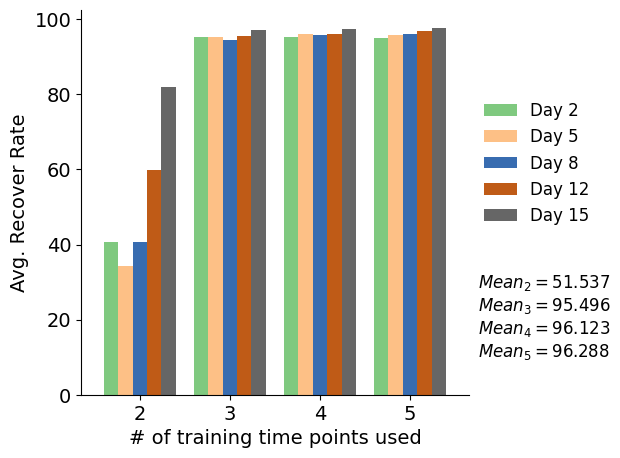

In [7]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 2', 'Day 5', 'Day 8', 'Day 12', 'Day 15']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)

### Panel E (ii)

In [8]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [9]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [10]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConst/dynamic', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

In [11]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

Text(3.75, 10, '$Mean_2 = 40.362$\n$Mean_3 = 80.888$\n$Mean_4 = 88.533$\n$Mean_5 = 89.935$')

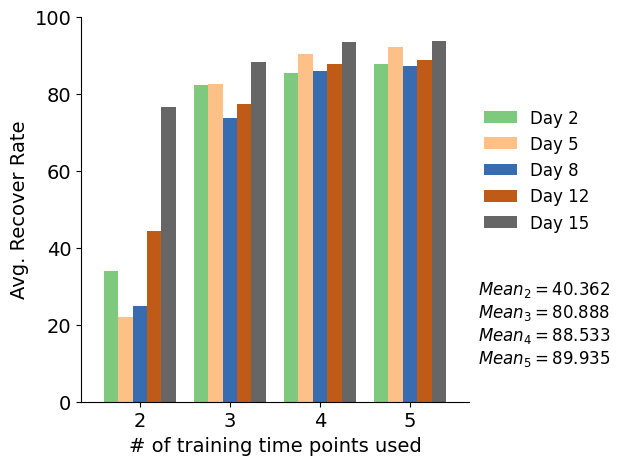

In [12]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 2', 'Day 5', 'Day 8', 'Day 12', 'Day 15']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)

### Panel E (iii)

In [13]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/CordBloodConstRates/0929_115228/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/CordBloodDynamicRates/0929_115437/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [14]:
from clonaltrans.data import simulation_const

K = model_const.get_matrix_K(eval=True)

N = simulation_const(
    K,
    model_const.L.detach().cpu(),
    model_const.config,
    torch.tensor([0.0, 2.0, 5.0, 8.0, 12.0, 15.0]).to(device),
    model_const.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [15]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsConstNoise', 
    N, 
    valid_times=[0.0, 2.0, 5.0, 8.0, 12.0, 15.0]
)

/tmp/ipykernel_85564/3175232886.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Accent')


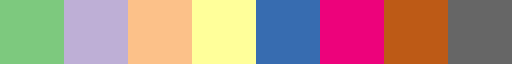

In [16]:
import matplotlib.cm as cm
cmap = cm.get_cmap('Accent')
cmap

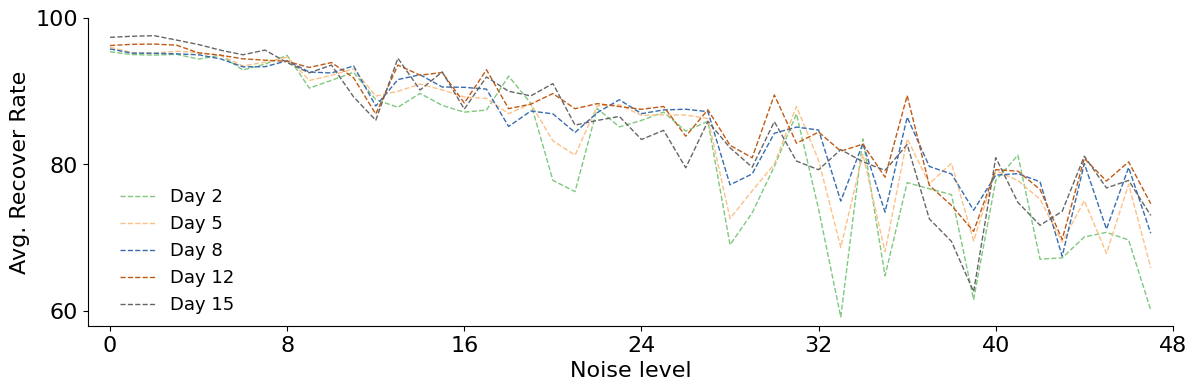

In [17]:
plt.figure(figsize=(14, 4))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.yticks([40, 60, 80, 100], [40, 60, 80, 100], fontsize=16)
plt.ylabel('Avg. Recover Rate', fontsize=16)
plt.ylim(58, 100)

plt.xlabel('Noise level', fontsize=16)
plt.xticks([0, 8, 16, 24, 32, 40, 48], [0, 8, 16, 24, 32, 40, 48], fontsize=16, rotation=0)
plt.plot([i for i in range(48)], [counts[i][0] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 2', color=cmap(0))
plt.plot([i for i in range(48)], [counts[i][1] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 5', color=cmap(2))
plt.plot([i for i in range(48)], [counts[i][2] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 8', color=cmap(4))
plt.plot([i for i in range(48)], [counts[i][3] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 12', color=cmap(6))
plt.plot([i for i in range(48)], [counts[i][4] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 15', color=cmap(7))
plt.legend(bbox_to_anchor=(0.15, 0.5), frameon=False, fontsize=13)

### Panel F (i)

In [18]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [19]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

In [20]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamic/const', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

In [21]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

Text(3.75, 10, '$Mean_2 = 53.865$\n$Mean_3 = 79.829$\n$Mean_4 = 83.354$\n$Mean_5 = 84.280$')

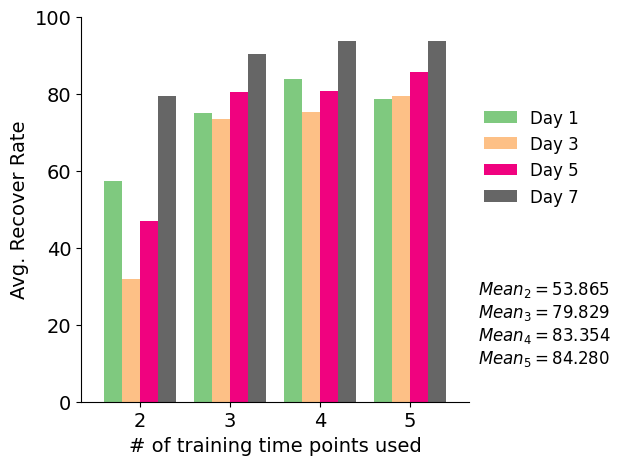

In [22]:
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 1', 'Day 3', 'Day 5', 'Day 7']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)

### Panel F (ii)

In [23]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [24]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [25]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamic/dynamic', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

In [26]:
text = f'$Mean_{2} = {np.mean(counts[0]):.3f}$\n$Mean_{3} = {np.mean(counts[1]):.3f}$\n$Mean_{4} = {np.mean(counts[2]):.3f}$\n$Mean_{5} = {np.mean(counts[3]):.3f}$'

Text(3.75, 10, '$Mean_2 = 30.347$\n$Mean_3 = 84.694$\n$Mean_4 = 84.310$\n$Mean_5 = 89.951$')

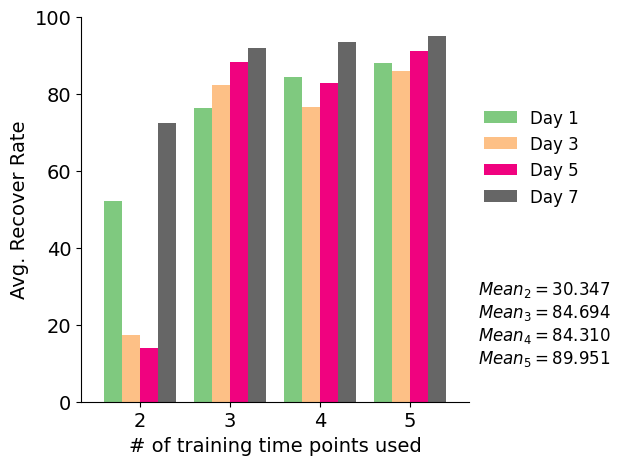

In [27]:
counts = [np.abs(i) for i in counts]
df = pd.DataFrame(counts)
df.index = ['2', '3', '4', '5']
df.columns = ['Day 1', 'Day 3', 'Day 5', 'Day 7']
ax = df.plot(kind='bar', stacked=False, figsize=(5,5), width=0.8, colormap='Accent')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1, 0.8), frameon=False, fontsize=12)
plt.xticks([0, 1, 2, 3], df.index, rotation=0, fontsize=14)
plt.yticks([0, 20, 40, 60, 80, 100], [0, 20, 40, 60, 80, 100], fontsize=14)
plt.ylabel('Avg. Recover Rate', fontsize=14)
plt.xlabel('# of training time points used', fontsize=14)
plt.text(3.75, 10, text, fontsize=12)

### Panel F (iii)

In [28]:
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/revision_1/checkpoints/WeinrebConstRates/0929_115327/model_last.pt'
model_const = torch.load(path, map_location='cpu')

path = '../trials/revision_1/checkpoints/WeinrebDynamicRates/0929_115710/model_last.pt'
model_dyna = torch.load(path, map_location='cpu')

device = torch.device('cpu')
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [29]:
from clonaltrans.data import simulation_dyna

K1_encode = model_dyna.model.block.K1_encode.detach()
K1_decode = model_dyna.model.block.K1_decode.detach()
K2_encode = model_dyna.model.block.K2_encode.detach()
K2_decode = model_dyna.model.block.K2_decode.detach()

N = simulation_dyna(
    K1_encode, K1_decode, K2_encode, K2_decode, 
    model_dyna.L.detach().cpu(), 
    model_dyna.config,
    torch.tensor([0.0, 1.0, 3.0, 5.0, 7.0]).to(device),
    model_dyna.N[0].detach().cpu()
)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [30]:
from clonaltrans.pl import get_corr_losses
corr, counts, corr_all_log = get_corr_losses(
    './trials/revision_1/checkpoints/SimulationsDynamicNoise', 
    N, 
    valid_times=[0.0, 1.0, 3.0, 5.0, 7.0]
)

/tmp/ipykernel_85564/3175232886.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Accent')


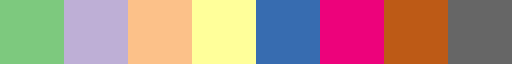

In [31]:
import matplotlib.cm as cm
cmap = cm.get_cmap('Accent')
cmap

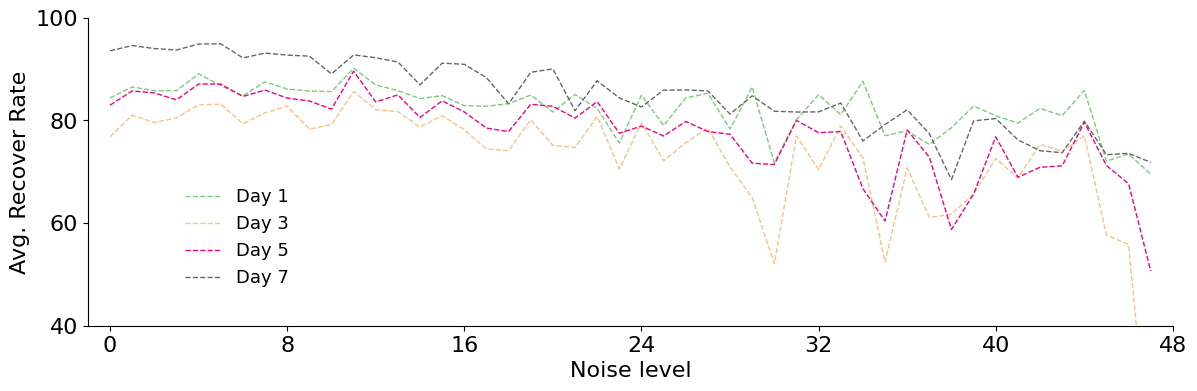

In [32]:
plt.figure(figsize=(14, 4))

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(left=-1)
ax.set_ylim(bottom=0)

plt.yticks([40, 60, 80, 100], [40, 60, 80, 100], fontsize=16)
plt.ylabel('Avg. Recover Rate', fontsize=16)
plt.ylim(40, 100)

plt.xlabel('Noise level', fontsize=16)
plt.xticks([0, 8, 16, 24, 32, 40, 48], [0, 8, 16, 24, 32, 40, 48], fontsize=16, rotation=0)
plt.plot([i for i in range(48)], [counts[i][0] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 1', color=cmap(0))
plt.plot([i for i in range(48)], [counts[i][1] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 3', color=cmap(2))
plt.plot([i for i in range(48)], [counts[i][2] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 5', color=cmap(5))
plt.plot([i for i in range(48)], [counts[i][3] for i in range(48)], linewidth=1, linestyle='dashed', label='Day 7', color=cmap(7))
plt.legend(bbox_to_anchor=(0.2, 0.5), frameon=False, fontsize=13)